# Data and Problem Framing
### Amazon Video Games Recommendation System

**Role:** Person 1 – Data and Problem Framing Lead  
**Dataset:** [Amazon Video Games Reviews](https://www.kaggle.com/datasets/gabrielfreddi/amazon-reviews-de-vdeo-games)

---
**Contents**
1. [Business Problem](#1-business-problem)
2. [Dataset Selection](#2-dataset-selection)
3. [Data Loading](#3-data-loading)
4. [Exploratory Data Analysis](#4-exploratory-data-analysis)
5. [Cleaning and Preprocessing](#5-cleaning-and-preprocessing)
6. [Train / Validation / Test Split](#6-train--validation--test-split)
7. [Save Outputs](#7-save-outputs)

---
## 1. Business Problem

The company currently displays products to users in a **random order**. Every user sees the same pool of products regardless of their preferences, history, or any behavioural signal — there is no personalisation whatsoever.

### Why random recommendations are weak

- **No personalisation** — users see products irrelevant to their interests, leading to low engagement
- **Wasted impressions** — products are shown to users who are very unlikely to buy them
- **Poor experience** — customers must search harder to find relevant items, reducing satisfaction
- **Missed revenue** — upsell and cross-sell opportunities are left on the table
- **No cold-start strategy** — even for new users, better heuristics (popularity, trends) exist

### Project goal

Replace the random baseline with an intelligent recommendation system that learns from past user behaviour, uses item content, and combines both signals in a hybrid approach. Every model will be evaluated against the random baseline using standard recommendation metrics (Precision@K, NDCG@K), and the business value of the improvement will be quantified.

> *If we show users the products they are most likely to buy — rather than random ones — we will increase engagement, increase sales, and improve customer satisfaction.*

---
## 2. Dataset Selection

### Candidates considered

| Dataset | Users | Items | Interactions | Text? | Metadata? | Decision |
|---|---|---|---|---|---|---|
| MovieLens 1M | 6,040 | 3,706 | 1,000,209 | No | Genre only | Too small, limited features |
| Yelp Reviews | ~2M | ~150K | ~7M | Yes | Yes | Non-product domain |
| Amazon Books | ~3M | ~400K | ~8M | Yes | Yes | Too large, text-heavy |
| **Amazon Video Games** | **1.54M** | **72K** | **2.57M** | **Yes** | **Yes** | **✅ Selected** |

### Why Amazon Video Games

**Source:** Kaggle — `gabrielfreddi/amazon-reviews-de-vdeo-games`  
**Files:** `Video_Games.json` (reviews) and `meta_Video_Games.json` (product metadata)

This dataset supports the full range of techniques required by the project:

| Technique | Signal available |
|---|---|
| Collaborative filtering | Explicit ratings (1–5★), user IDs, item IDs |
| Content-based (TF-IDF, BERT, NER) | Review text (~100% coverage), product descriptions (88%), titles (100%) |
| Hybrid | Both signals above |
| Context-aware / temporal | Timestamps spanning 20 years (1997–2018) |
| Demographic filtering | Platform info (Xbox, PlayStation, PC) via `style` field |
| Business narrative | Video games is an intuitive, relatable domain for a CEO audience |

### Known limitations

| Limitation | Mitigation |
|---|---|
| High sparsity — median user has only 1 review | Apply 5-core filter (keep users and items with ≥5 reviews) |
| No explicit demographics | Use `style` field (platform) as a demographic proxy |
| 62% of ratings are 5-star | Use ranking metrics (NDCG, MAP) alongside RMSE |

---
## 3. Data Loading

In [1]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import kagglehub

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

PROC_DIR = '../data/processed/'
os.makedirs(PROC_DIR, exist_ok=True)

# Download dataset (cached after first run)
# Requires ~/.kaggle/kaggle.json — see README for setup
print('Fetching dataset via kagglehub...')
DATASET_DIR  = kagglehub.dataset_download('gabrielfreddi/amazon-reviews-de-vdeo-games')
REVIEWS_PATH = os.path.join(DATASET_DIR, 'Video_Games.json')
META_PATH    = os.path.join(DATASET_DIR, 'meta_Video_Games.json')
print(f'Dataset ready at: {DATASET_DIR}')

Fetching dataset via kagglehub...


Dataset ready at: /Users/sofiaclaudiabonoan/.cache/kagglehub/datasets/gabrielfreddi/amazon-reviews-de-vdeo-games/versions/2


In [2]:
def load_jsonl(filepath):
    """Load a newline-delimited JSON file into a DataFrame."""
    records = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            try:
                records.append(json.loads(line))
            except json.JSONDecodeError:
                pass
    return pd.DataFrame(records)

print('Loading reviews...')
reviews_raw = load_jsonl(REVIEWS_PATH)
print(f'  {len(reviews_raw):,} reviews loaded  |  columns: {list(reviews_raw.columns)}')

print('Loading metadata...')
meta_raw = load_jsonl(META_PATH)
print(f'  {len(meta_raw):,} products loaded  |  columns: {list(meta_raw.columns)}')

Loading reviews...


  2,565,349 reviews loaded  |  columns: ['overall', 'verified', 'reviewTime', 'reviewerID', 'asin', 'reviewerName', 'reviewText', 'summary', 'unixReviewTime', 'vote', 'style', 'image']
Loading metadata...


  84,819 products loaded  |  columns: ['category', 'tech1', 'description', 'fit', 'title', 'also_buy', 'tech2', 'brand', 'feature', 'rank', 'also_view', 'main_cat', 'similar_item', 'date', 'price', 'asin', 'imageURL', 'imageURLHighRes', 'details']


---
## 4. Exploratory Data Analysis

### 4.1 Overview

In [3]:
n_reviews    = len(reviews_raw)
n_users      = reviews_raw['reviewerID'].nunique()
n_items      = reviews_raw['asin'].nunique()
n_meta_items = meta_raw['asin'].nunique()
sparsity     = 1 - (n_reviews / (n_users * n_items))
ts_min = pd.to_datetime(reviews_raw['unixReviewTime'], unit='s').min()
ts_max = pd.to_datetime(reviews_raw['unixReviewTime'], unit='s').max()

print(f'Total reviews          : {n_reviews:>12,}')
print(f'Unique users           : {n_users:>12,}')
print(f'Unique items (reviews) : {n_items:>12,}')
print(f'Unique items (metadata): {n_meta_items:>12,}')
print(f'Matrix sparsity        : {sparsity:>12.4%}')
print(f'Date range             : {ts_min.date()} → {ts_max.date()} ({(ts_max-ts_min).days//365} years)')

Total reviews          :    2,565,349
Unique users           :    1,540,618
Unique items (reviews) :       71,982
Unique items (metadata):       71,911
Matrix sparsity        :     99.9977%
Date range             : 1997-11-08 → 2018-10-02 (20 years)


### 4.2 Missing Values

In [4]:
print('── Reviews ───────────────────────────────')
missing = reviews_raw.isnull().sum()
pct     = (missing / len(reviews_raw) * 100).round(2)
display(pd.DataFrame({'missing': missing, '%': pct})[lambda x: x['missing'] > 0].sort_values('%', ascending=False))

print('\n── Metadata ──────────────────────────────')
def count_empty(s):
    def empty(x):
        if x is None: return True
        if isinstance(x, float) and np.isnan(x): return True
        if isinstance(x, (list, dict)) and len(x) == 0: return True
        if isinstance(x, str) and x.strip() == '': return True
        return False
    return s.apply(empty).sum()

meta_miss = {c: count_empty(meta_raw[c]) for c in meta_raw.columns}
meta_miss_df = pd.DataFrame.from_dict(meta_miss, orient='index', columns=['empty'])
meta_miss_df['%'] = (meta_miss_df['empty'] / len(meta_raw) * 100).round(1)
display(meta_miss_df.sort_values('%', ascending=False))

── Reviews ───────────────────────────────


,missing,%
image,2537044,98.90
vote,2122633,82.74
style,1245377,48.55
reviewText,1715,0.07
summary,811,0.03
reviewerName,253,0.01



── Metadata ──────────────────────────────


,empty,%
fit,84819,100.0
tech2,84585,99.7
similar_item,84538,99.7
details,82590,97.4
tech1,81972,96.6
date,74762,88.1
also_buy,49424,58.3
also_view,39778,46.9
price,25460,30.0
imageURLHighRes,22863,27.0


### 4.3 Duplicates

In [5]:
dup_reviews = reviews_raw.duplicated(subset=['reviewerID', 'asin'], keep=False).sum()
dup_meta    = meta_raw.duplicated(subset=['asin'], keep=False).sum()
print(f'Duplicate (user, item) pairs in reviews : {dup_reviews:,}')
print(f'Duplicate ASINs in metadata             : {dup_meta:,}')

Duplicate (user, item) pairs in reviews : 151,648
Duplicate ASINs in metadata             : 25,816


### 4.4 Rating Distribution

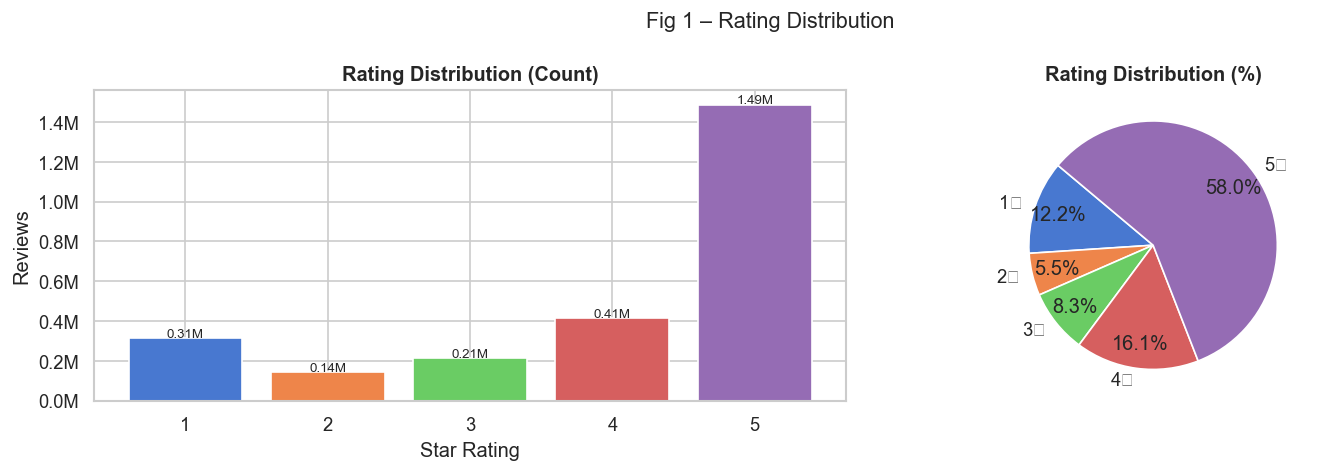

Note: 58.0% of reviews are 5-star — strong positive skew.


In [6]:
rating_counts = reviews_raw['overall'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(rating_counts.index.astype(int), rating_counts.values,
            color=sns.color_palette('muted'), edgecolor='white')
axes[0].set_title('Rating Distribution (Count)', fontweight='bold')
axes[0].set_xlabel('Star Rating')
axes[0].set_ylabel('Reviews')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
for bar, val in zip(axes[0].patches, rating_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
                 f'{val/1e6:.2f}M', ha='center', fontsize=8)

axes[1].pie(rating_counts.values, labels=[f'{int(r)}★' for r in rating_counts.index],
            autopct='%1.1f%%', colors=sns.color_palette('muted'), startangle=140, pctdistance=0.8)
axes[1].set_title('Rating Distribution (%)', fontweight='bold')

plt.suptitle('Fig 1 – Rating Distribution', fontsize=13)
plt.tight_layout()
plt.savefig(f'{PROC_DIR}fig1_rating_distribution.png', bbox_inches='tight')
plt.show()
print(f'Note: {rating_counts[5.0]/len(reviews_raw):.1%} of reviews are 5-star — strong positive skew.')

### 4.5 User Activity

Min / Median / Mean / Max reviews per user: 1 / 1 / 1.67 / 888

  Users with ≥  1 reviews: 1,540,618  (100.0%)
  Users with ≥  2 reviews:  413,222  (26.8%)
  Users with ≥  5 reviews:   64,087  (4.2%)
  Users with ≥ 10 reviews:   15,517  (1.0%)
  Users with ≥ 20 reviews:    3,627  (0.2%)


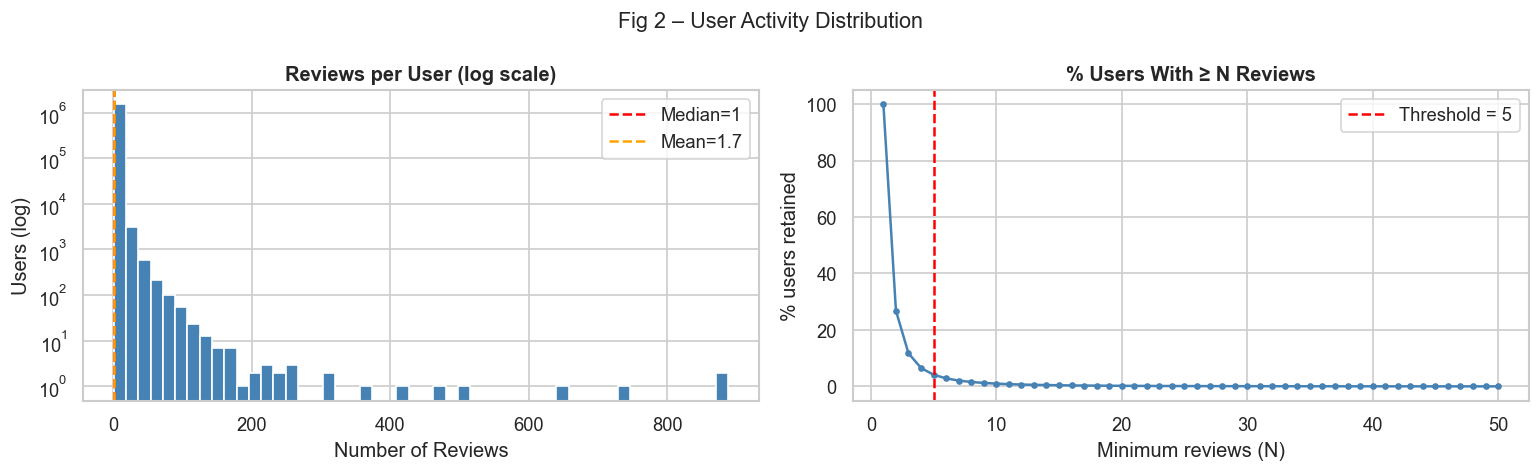

In [7]:
user_activity = reviews_raw['reviewerID'].value_counts()

print(f'Min / Median / Mean / Max reviews per user: '
      f'{user_activity.min()} / {user_activity.median():.0f} / {user_activity.mean():.2f} / {user_activity.max()}')
print()
for t in [1, 2, 5, 10, 20]:
    n = (user_activity >= t).sum()
    print(f'  Users with ≥ {t:2d} reviews: {n:>8,}  ({n/len(user_activity):.1%})')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(user_activity.values, bins=50, color='steelblue', edgecolor='white', log=True)
axes[0].set_title('Reviews per User (log scale)', fontweight='bold')
axes[0].set_xlabel('Number of Reviews')
axes[0].set_ylabel('Users (log)')
axes[0].axvline(user_activity.median(), color='red',    linestyle='--', label=f'Median={int(user_activity.median())}')
axes[0].axvline(user_activity.mean(),   color='orange', linestyle='--', label=f'Mean={user_activity.mean():.1f}')
axes[0].legend()

pct_users = [(user_activity >= t).sum() / len(user_activity) * 100 for t in range(1, 51)]
axes[1].plot(range(1, 51), pct_users, marker='o', markersize=3, color='steelblue')
axes[1].axvline(5, color='red', linestyle='--', label='Threshold = 5')
axes[1].set_title('% Users With ≥ N Reviews', fontweight='bold')
axes[1].set_xlabel('Minimum reviews (N)')
axes[1].set_ylabel('% users retained')
axes[1].legend()

plt.suptitle('Fig 2 – User Activity Distribution', fontsize=13)
plt.tight_layout()
plt.savefig(f'{PROC_DIR}fig2_user_activity.png', bbox_inches='tight')
plt.show()

### 4.6 Item Popularity

Min / Median / Mean / Max reviews per item: 1 / 5 / 35.64 / 7630

  Items with ≥  1 reviews:  71,982  (100.0%)
  Items with ≥  5 reviews:  37,153  (51.6%)
  Items with ≥ 10 reviews:  26,431  (36.7%)
  Items with ≥ 20 reviews:  17,894  (24.9%)
  Items with ≥ 50 reviews:   9,383  (13.0%)


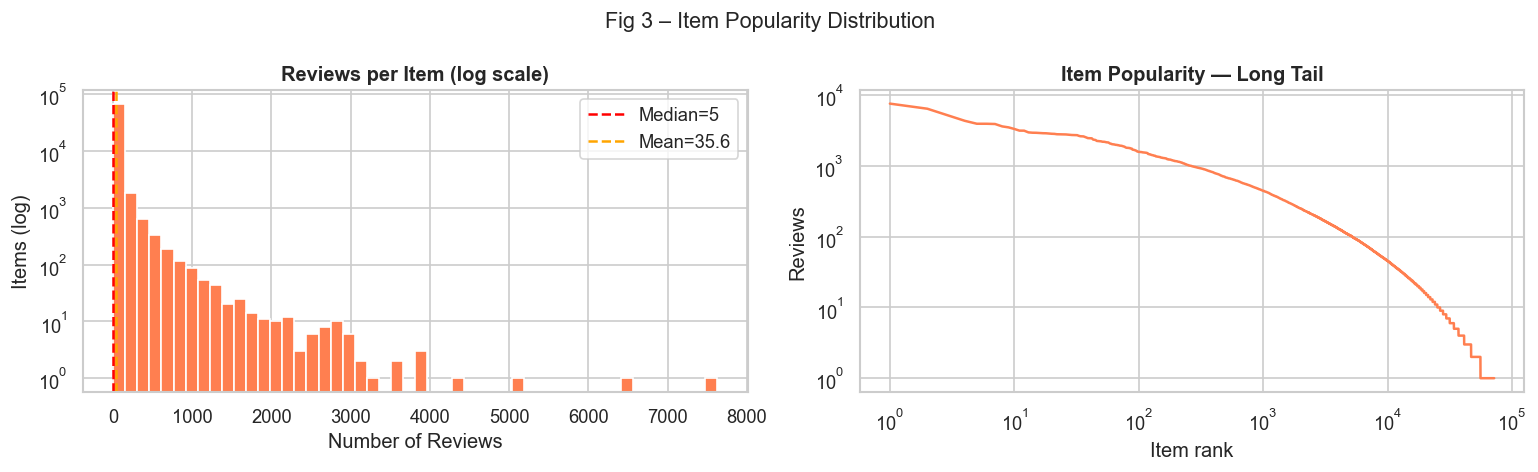

In [8]:
item_popularity = reviews_raw['asin'].value_counts()

print(f'Min / Median / Mean / Max reviews per item: '
      f'{item_popularity.min()} / {item_popularity.median():.0f} / {item_popularity.mean():.2f} / {item_popularity.max()}')
print()
for t in [1, 5, 10, 20, 50]:
    n = (item_popularity >= t).sum()
    print(f'  Items with ≥ {t:2d} reviews: {n:>7,}  ({n/len(item_popularity):.1%})')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(item_popularity.values, bins=50, color='coral', edgecolor='white', log=True)
axes[0].set_title('Reviews per Item (log scale)', fontweight='bold')
axes[0].set_xlabel('Number of Reviews')
axes[0].set_ylabel('Items (log)')
axes[0].axvline(item_popularity.median(), color='red',    linestyle='--', label=f'Median={int(item_popularity.median())}')
axes[0].axvline(item_popularity.mean(),   color='orange', linestyle='--', label=f'Mean={item_popularity.mean():.1f}')
axes[0].legend()

axes[1].plot(range(1, len(item_popularity)+1), item_popularity.values, color='coral')
axes[1].set_title('Item Popularity — Long Tail', fontweight='bold')
axes[1].set_xlabel('Item rank')
axes[1].set_ylabel('Reviews')
axes[1].set_yscale('log')
axes[1].set_xscale('log')

plt.suptitle('Fig 3 – Item Popularity Distribution', fontsize=13)
plt.tight_layout()
plt.savefig(f'{PROC_DIR}fig3_item_popularity.png', bbox_inches='tight')
plt.show()

### 4.7 Top 20 Most Reviewed Products

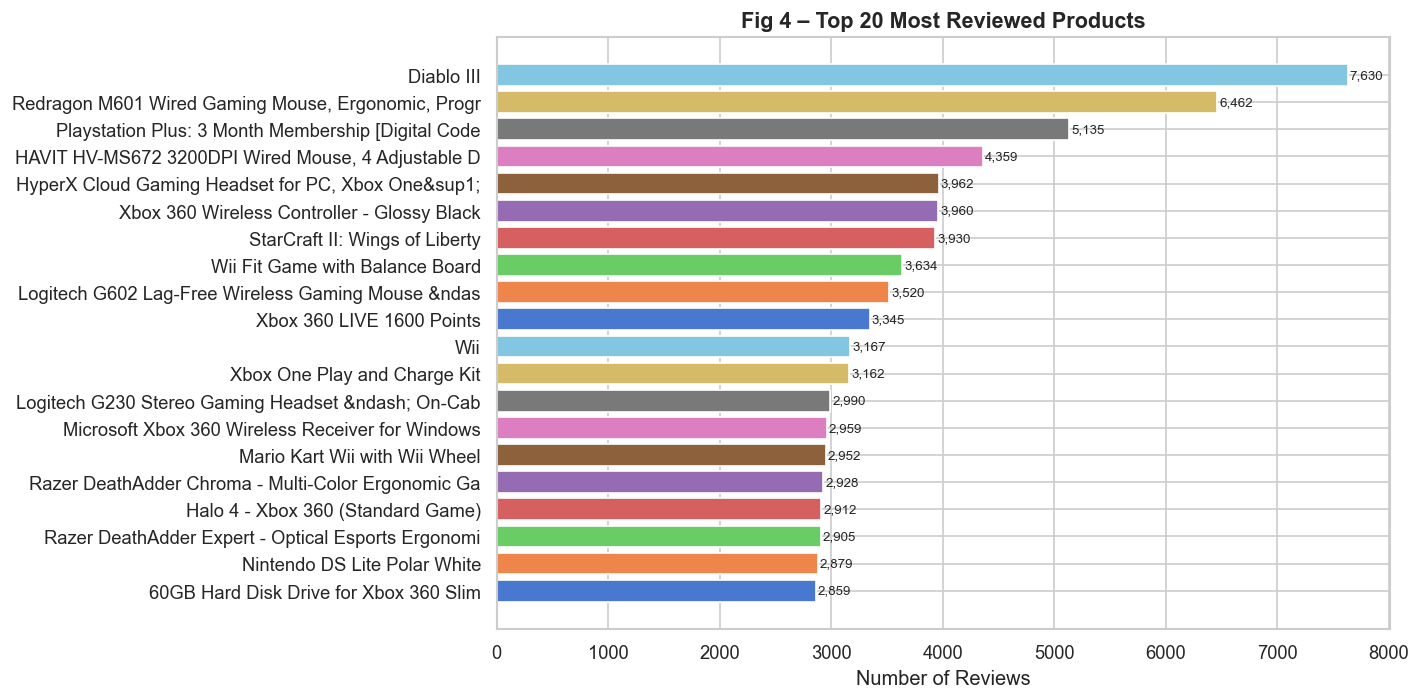

In [9]:
top20 = (item_popularity.head(20)
         .reset_index()
         .rename(columns={'asin': 'asin', 'count': 'review_count'}))
top20.columns = ['asin', 'review_count']
top20 = top20.merge(meta_raw[['asin','title']].drop_duplicates('asin'), on='asin', how='left')
top20['label'] = top20['title'].fillna('Unknown').str[:50]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top20['label'][::-1], top20['review_count'][::-1], color=sns.color_palette('muted', 20))
for bar, val in zip(bars, top20['review_count'][::-1]):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2, f'{val:,}', va='center', fontsize=8)
ax.set_xlabel('Number of Reviews')
ax.set_title('Fig 4 – Top 20 Most Reviewed Products', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PROC_DIR}fig4_top20_items.png', bbox_inches='tight')
plt.show()

### 4.8 Review Volume Over Time

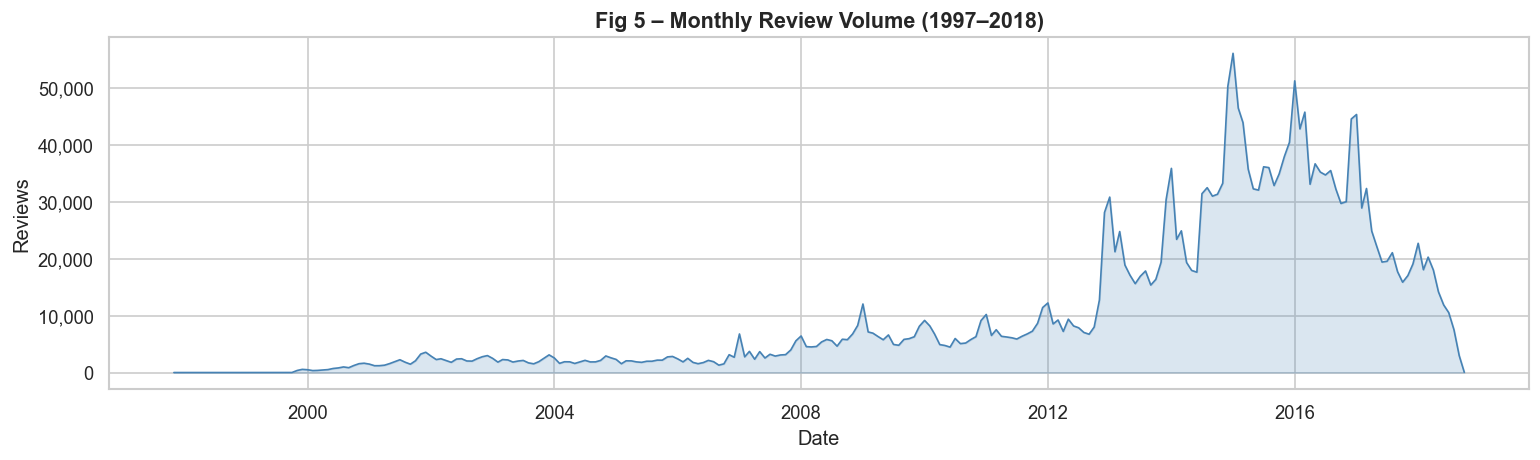

In [10]:
reviews_raw['review_date'] = pd.to_datetime(reviews_raw['unixReviewTime'], unit='s')
monthly = reviews_raw.groupby(reviews_raw['review_date'].dt.to_period('M')).size()
monthly.index = monthly.index.to_timestamp()

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(monthly.index, monthly.values, linewidth=1, color='steelblue')
ax.fill_between(monthly.index, monthly.values, alpha=0.2, color='steelblue')
ax.set_title('Fig 5 – Monthly Review Volume (1997–2018)', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Reviews')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(f'{PROC_DIR}fig5_reviews_over_time.png', bbox_inches='tight')
plt.show()

### 4.9 Sparsity

In [11]:
total_possible = n_users * n_items
density        = n_reviews / total_possible

print(f'Matrix: {n_users:,} users × {n_items:,} items')
print(f'Possible cells : {total_possible:,.0f}')
print(f'Filled cells   : {n_reviews:,}  ({density:.6%} density)')
print(f'Sparsity       : {1-density:.6%}')
print()
print('This extreme sparsity is typical of real-world recommendation datasets.')
print('It motivates the 5-core filter applied in the preprocessing step below.')

Matrix: 1,540,618 users × 71,982 items
Possible cells : 110,896,764,876
Filled cells   : 2,565,349  (0.002313% density)
Sparsity       : 99.997687%

This extreme sparsity is typical of real-world recommendation datasets.
It motivates the 5-core filter applied in the preprocessing step below.


### 4.10 Metadata Sample

In [12]:
sample = meta_raw[['asin','title','brand','category','price','description']].dropna(subset=['title']).head(5)
for _, row in sample.iterrows():
    desc = row['description']
    desc_text = str(desc[0])[:100] if isinstance(desc, list) and desc else ''
    print(f"ASIN  : {row['asin']}")
    print(f"Title : {str(row['title'])[:80]}")
    print(f"Brand : {row['brand']}  |  Price: {row['price']}")
    print(f"Cat   : {row['category']}")
    if desc_text:
        print(f"Desc  : {desc_text}")
    print()

ASIN  : 0042000742
Title : Reversi Sensory Challenger
Brand : Fidelity Electronics  |  Price: 
Cat   : ['Video Games', 'PC', 'Games']

ASIN  : 0078764343
Title : Medal of Honor: Warfighter - Includes Battlefield 4 Beta - Limited Edition
Brand : by
    
    EA Games  |  Price: 
												<span class="verticalAlign a-size-large"
Cat   : ['Video Games', 'Xbox 360', 'Games', '</span></span></span>']
Desc  : Brand new sealed!

ASIN  : 0276425316
Title : street fighter 2 II turbo super nintendo snes super nes video game
Brand : Nintendo  |  Price: $0.72
Cat   : ['Video Games', 'Retro Gaming & Microconsoles', 'Super Nintendo', 'Games']

ASIN  : 0324411812
Title : Xbox 360 MAS STICK
Brand : by
    
    MAS SYSTEMS  |  Price: 
Cat   : ['Video Games', 'Xbox 360', 'Accessories', 'Controllers', 'Joysticks', '</span></span></span>', 'Original PCB used from Xbox 360 Control Pad (to ensure 100% compatibility)', 'FULL SIZE MAS STICK', 'Special Design for Xbox 360 (Street Fighter Button Layout)', 'Us

---
## 5. Cleaning and Preprocessing

### 5.1 Clean reviews

In [13]:
reviews = reviews_raw.copy()
print(f'Start: {len(reviews):,} rows')

# Drop rows missing essential fields
reviews = reviews.dropna(subset=['reviewerID', 'asin', 'overall'])
print(f'After dropping missing user/item/rating: {len(reviews):,}')

# Remove duplicate (user, item) pairs — keep most recent review
reviews = reviews.sort_values('unixReviewTime', ascending=False)
reviews = reviews.drop_duplicates(subset=['reviewerID', 'asin'], keep='first')
print(f'After removing duplicate (user, item) pairs: {len(reviews):,}')

# Standardise column names
reviews = reviews.rename(columns={
    'reviewerID'    : 'user_id',
    'asin'          : 'item_id',
    'overall'       : 'rating',
    'unixReviewTime': 'timestamp',
    'reviewText'    : 'review_text',
    'summary'       : 'review_summary',
    'reviewerName'  : 'user_name',
})
reviews['rating']      = reviews['rating'].astype(float)
reviews['timestamp']   = reviews['timestamp'].astype(int)
reviews['review_date'] = pd.to_datetime(reviews['timestamp'], unit='s')
reviews = reviews[['user_id','item_id','rating','timestamp','review_date','review_text','review_summary','verified']]

print(f'Final reviews: {len(reviews):,}  |  columns: {list(reviews.columns)}')
reviews.head(3)

Start: 2,565,349 rows
After dropping missing user/item/rating: 2,565,349


After removing duplicate (user, item) pairs: 2,489,395
Final reviews: 2,489,395  |  columns: ['user_id', 'item_id', 'rating', 'timestamp', 'review_date', 'review_text', 'review_summary', 'verified']


,user_id,item_id,rating,timestamp,review_date,review_text,review_summary,verified
2563951,APYUD3QMY7AQR,B01H482N6E,4.0,1538438400,2018-10-02,The pokemon Go Plus worked wonderfully..but I ...,pokemon go plus,True
2562954,A2VCURO9TSCFD7,B01GW8YDLK,5.0,1538438400,2018-10-02,This is an awesome game. The graphics are amaz...,Awesome Game,False
2563600,A1BFYATNH97BMV,B01H1GJ7IQ,5.0,1538438400,2018-10-02,Great,Five Stars,True


### 5.2 Filter — 5-core

We apply an iterative **5-core filter**: keep only users with ≥ 5 reviews and items with ≥ 5 reviews. This is standard practice in the recommender systems literature to ensure collaborative filtering has enough signal per user and that evaluation metrics are meaningful.

In [14]:
def kcore_filter(df, min_user=5, min_item=5, max_iter=10):
    for i in range(max_iter):
        n_before    = len(df)
        valid_users = df['user_id'].value_counts()
        valid_items = df['item_id'].value_counts()
        df = df[
            df['user_id'].isin(valid_users[valid_users >= min_user].index) &
            df['item_id'].isin(valid_items[valid_items >= min_item].index)
        ]
        if len(df) == n_before:
            print(f'Converged after {i+1} iteration(s).')
            break
    return df

print(f'Before: {len(reviews):,} interactions | {reviews["user_id"].nunique():,} users | {reviews["item_id"].nunique():,} items')
reviews_filtered = kcore_filter(reviews)

n_f  = len(reviews_filtered)
nu_f = reviews_filtered['user_id'].nunique()
ni_f = reviews_filtered['item_id'].nunique()

print(f'After : {n_f:,} interactions | {nu_f:,} users | {ni_f:,} items')
print(f'Retained: {n_f/len(reviews):.1%} of interactions | {nu_f/reviews["user_id"].nunique():.1%} of users | {ni_f/reviews["item_id"].nunique():.1%} of items')
print(f'New sparsity: {1 - n_f/(nu_f*ni_f):.4%}')

Before: 2,489,395 interactions | 1,540,618 users | 71,982 items


After : 453,885 interactions | 50,627 users | 16,882 items


Retained: 18.2% of interactions | 3.3% of users | 23.5% of items
New sparsity: 99.9469%


### 5.3 Clean metadata

In [15]:
import re

meta = meta_raw[meta_raw['asin'].isin(reviews_filtered['item_id'])].copy()
meta = meta.rename(columns={'asin': 'item_id'})

# Clean price
def clean_price(p):
    if not isinstance(p, str) or not p.strip(): return np.nan
    m = re.search(r'[\d]+\.?[\d]*', p.replace(',', ''))
    return float(m.group()) if m else np.nan

meta['price_clean']       = meta['price'].apply(clean_price)
meta['description_text']  = meta['description'].apply(lambda x: ' '.join(x) if isinstance(x, list) else (x or ''))
meta['features_text']     = meta['feature'].apply(lambda x: ' '.join(x) if isinstance(x, list) else '')
meta['main_category']     = meta['category'].apply(lambda x: x[0] if isinstance(x, list) and x else 'Unknown')
meta['sub_category']      = meta['category'].apply(lambda x: x[1] if isinstance(x, list) and len(x) > 1 else 'Unknown')

# Combined text field for Person 3 (content-based models)
meta['content_text'] = (
    meta['title'].fillna('') + ' ' +
    meta['description_text'].fillna('') + ' ' +
    meta['features_text'].fillna('') + ' ' +
    meta['brand'].fillna('') + ' ' +
    meta['main_category'].fillna('')
)

meta = meta[['item_id','title','brand','main_category','sub_category',
             'price_clean','description_text','features_text','content_text',
             'also_buy','also_view']]

print(f'Cleaned metadata: {len(meta):,} items  |  columns: {list(meta.columns)}')
meta.head(3)

Cleaned metadata: 20,529 items  |  columns: ['item_id', 'title', 'brand', 'main_category', 'sub_category', 'price_clean', 'description_text', 'features_text', 'content_text', 'also_buy', 'also_view']


,item_id,title,brand,main_category,sub_category,price_clean,description_text,features_text,content_text,also_buy,also_view
38,0700026657,Anno 2070,Ubisoft,Video Games,PC,7.95,ANNO 2070BRAND NEW - IN STOCKDVD Rom Software ...,A new era: while adhering to the fundamentals ...,Anno 2070 ANNO 2070BRAND NEW - IN STOCKDVD Rom...,[],"[B013F0IP1C, B00JDP1AWU, B00XR3YC2E, B001AWMCM..."
39,0700026398,HITMAN ABSOLUTION (PC),Square Enix,Video Games,PC,NaN,"Hitman: Absolution follows Agent 47, a cold-bl...",PC-DVD Import Showcasing Glacier 2 technology ...,HITMAN ABSOLUTION (PC) Hitman: Absolution foll...,[],[]
41,0700099867,Dirt 3,Dirt 3,Video Games,PC,NaN,Dirt 3 is a popular rally racing game for Play...,"DiRT 3 delivers mud, sweat and gears the world...",Dirt 3 Dirt 3 is a popular rally racing game f...,[],[]


### 5.4 Build output tables

In [16]:
# User table
user_table = reviews_filtered.groupby('user_id').agg(
    n_reviews   = ('rating', 'count'),
    avg_rating  = ('rating', 'mean'),
    first_review= ('timestamp', 'min'),
    last_review = ('timestamp', 'max'),
).reset_index()
user_table['avg_rating'] = user_table['avg_rating'].round(2)

# Item table
item_stats = reviews_filtered.groupby('item_id').agg(
    n_reviews  = ('rating', 'count'),
    avg_rating = ('rating', 'mean'),
).reset_index()
item_stats['avg_rating'] = item_stats['avg_rating'].round(2)
item_table = item_stats.merge(
    meta[['item_id','title','brand','main_category','sub_category','price_clean']],
    on='item_id', how='left'
)

# Interaction table
interaction_table = reviews_filtered[['user_id','item_id','rating','timestamp','review_date','verified']].copy()

print(f'User table       : {len(user_table):,} rows')
print(f'Item table       : {len(item_table):,} rows')
print(f'Interaction table: {len(interaction_table):,} rows')

User table       : 50,627 rows
Item table       : 20,546 rows
Interaction table: 453,885 rows


---
## 6. Train / Validation / Test Split

We use a **time-based per-user split** (70% train / 15% validation / 15% test) rather than a random split. A random split would allow future reviews to leak into training — the model would be trained on information it could not have known at inference time. A temporal split simulates real deployment and is considered best practice in the recommendation systems literature.

Each user's interactions are sorted chronologically and divided independently, ensuring every user appears in the training set.

In [17]:
def time_split(df, train_frac=0.70, val_frac=0.15):
    train_idx, val_idx, test_idx = [], [], []
    for _, user_df in df.sort_values('timestamp').groupby('user_id'):
        n = len(user_df)
        if n < 3:
            train_idx.extend(user_df.index.tolist())
            continue
        n_train = max(1, int(n * train_frac))
        n_val   = max(1, int(n * val_frac))
        train_idx.extend(user_df.iloc[:n_train].index.tolist())
        val_idx.extend(user_df.iloc[n_train:n_train+n_val].index.tolist())
        test_idx.extend(user_df.iloc[n_train+n_val:].index.tolist())
    return df.loc[train_idx].copy(), df.loc[val_idx].copy(), df.loc[test_idx].copy()

train, val, test = time_split(interaction_table)
total = len(interaction_table)

print(f'Train : {len(train):>8,}  ({len(train)/total:.1%})')
print(f'Val   : {len(val):>8,}  ({len(val)/total:.1%})')
print(f'Test  : {len(test):>8,}  ({len(test)/total:.1%})')
print()
print(f'Train date range: {pd.to_datetime(train["timestamp"].min(),unit="s").date()} → {pd.to_datetime(train["timestamp"].max(),unit="s").date()}')
print(f'Val   date range: {pd.to_datetime(val["timestamp"].min(),unit="s").date()} → {pd.to_datetime(val["timestamp"].max(),unit="s").date()}')
print(f'Test  date range: {pd.to_datetime(test["timestamp"].min(),unit="s").date()} → {pd.to_datetime(test["timestamp"].max(),unit="s").date()}')

# Leakage check
unseen_val  = set(val['user_id'])  - set(train['user_id'])
unseen_test = set(test['user_id']) - set(train['user_id'])
print(f'\nLeakage check — users in val/test not in train: {len(unseen_val)} / {len(unseen_test)}  (expected: 0)')

Train :  294,149  (64.8%)
Val   :   64,461  (14.2%)
Test  :   95,275  (21.0%)

Train date range: 1999-10-14 → 2018-09-22
Val   date range: 1999-12-05 → 2018-09-22
Test  date range: 1999-12-05 → 2018-10-02



Leakage check — users in val/test not in train: 0 / 0  (expected: 0)


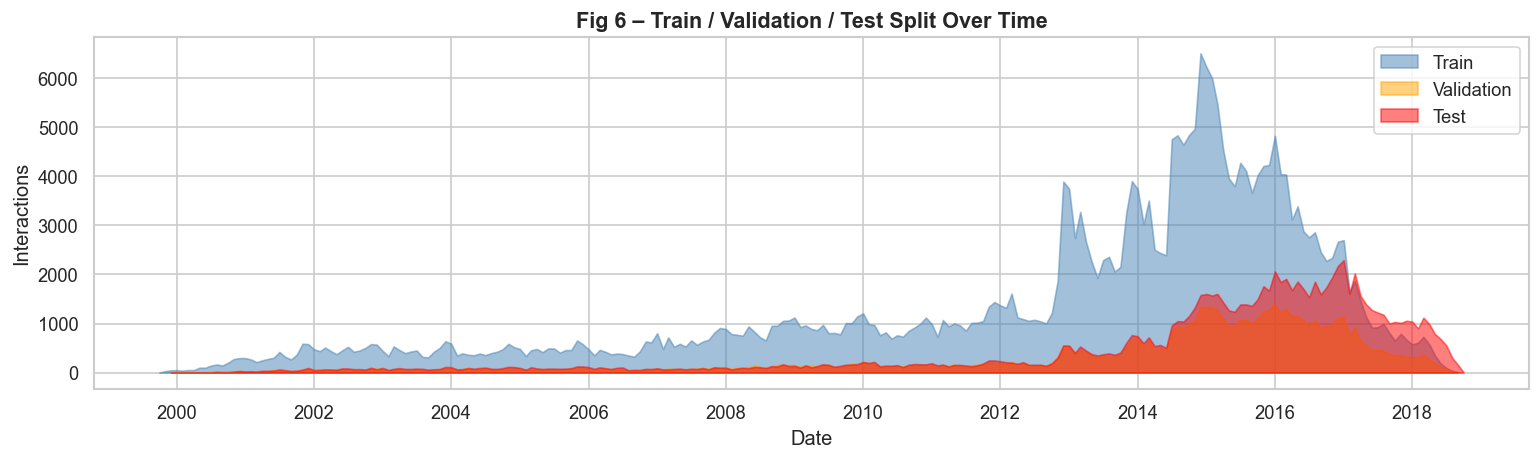

In [18]:
fig, ax = plt.subplots(figsize=(13, 4))
for split, color, label in [(train,'steelblue','Train'),(val,'orange','Validation'),(test,'red','Test')]:
    s = split.copy()
    s['ym'] = pd.to_datetime(s['timestamp'], unit='s').dt.to_period('M').dt.to_timestamp()
    cnt = s.groupby('ym').size()
    ax.fill_between(cnt.index, cnt.values, alpha=0.5, label=label, color=color)
ax.set_title('Fig 6 – Train / Validation / Test Split Over Time', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Interactions')
ax.legend()
plt.tight_layout()
plt.savefig(f'{PROC_DIR}fig6_train_val_test_split.png', bbox_inches='tight')
plt.show()

---
## 7. Save Outputs

All cleaned tables are saved to `data/processed/` for use by the rest of the team.

In [19]:
files = {
    'interactions_clean.csv': interaction_table,
    'users.csv'             : user_table,
    'items.csv'             : item_table,
    'metadata_clean.csv'    : meta,
    'train.csv'             : train,
    'val.csv'               : val,
    'test.csv'              : test,
}
for fname, df in files.items():
    df.to_csv(f'{PROC_DIR}{fname}', index=False)
    print(f'  ✓  {fname:<30} {len(df):>8,} rows')

print(f'\nAll files saved to {PROC_DIR}')
print(f'\nSummary')
print(f'  Interactions : {len(interaction_table):,}')
print(f'  Users        : {len(user_table):,}')
print(f'  Items        : {len(item_table):,}')
print(f'  Sparsity     : {1 - len(interaction_table)/(len(user_table)*len(item_table)):.4%}')
print(f'  Train/Val/Test: {len(train):,} / {len(val):,} / {len(test):,}')
print(f'\n⚠️  Do not use test.csv until final evaluation (Person 4).')

  ✓  interactions_clean.csv          453,885 rows
  ✓  users.csv                        50,627 rows
  ✓  items.csv                        20,546 rows


  ✓  metadata_clean.csv               20,529 rows


  ✓  train.csv                       294,149 rows
  ✓  val.csv                          64,461 rows


  ✓  test.csv                         95,275 rows

All files saved to ../data/processed/

Summary
  Interactions : 453,885
  Users        : 50,627
  Items        : 20,546
  Sparsity     : 99.9564%
  Train/Val/Test: 294,149 / 64,461 / 95,275

⚠️  Do not use test.csv until final evaluation (Person 4).


---
## Handover to Person 2

Everything Person 1 was responsible for is complete. Here is a summary of what was done and what Person 2 needs to know before starting.

---

### What Person 1 completed

| # | Task | Status | Result |
|---|---|---|---|
| 1 | Business problem statement | ✅ Done | Section 1 — explains random baseline, its weaknesses, and the project goal |
| 2 | Dataset selection & comparison | ✅ Done | Section 2 — 4 candidates compared, Amazon Video Games selected |
| 3 | Dataset justification | ✅ Done | Section 2 — supports collab filtering, content-based, hybrid, and temporal methods |
| 4 | Exploratory data analysis | ✅ Done | Section 4 — 10 subsections, 6 visualisations saved to `data/processed/` |
| 5 | Data cleaning & preprocessing | ✅ Done | Section 5 — deduplication, missing values, column standardisation, 5-core filter |
| 6 | Train / validation / test split | ✅ Done | Section 6 — time-based per-user split, zero leakage confirmed |
| 7 | Cleaned output files | ✅ Done | Section 7 — 7 CSV files saved to `data/processed/` |

---

### Files ready in `data/processed/`

| File | Rows | Use for |
|---|---|---|
| `train.csv` | 294,149 | Training all your models |
| `val.csv` | 64,461 | Tuning and intermediate evaluation |
| `test.csv` | 95,275 | **Final evaluation only — do not use until all models are built** |
| `interactions_clean.csv` | 453,885 | Full clean interaction matrix (all splits combined) |
| `users.csv` | 50,627 | User-level stats (n_reviews, avg_rating, first/last review date) |
| `items.csv` | 20,546 | Item-level stats + title, brand, category, price |
| `metadata_clean.csv` | 20,529 | Full cleaned metadata — **pass this to Person 3 for content-based models** |

---

### Column reference for `train.csv` / `val.csv` / `test.csv`

| Column | Type | Description |
|---|---|---|
| `user_id` | string | Unique user identifier |
| `item_id` | string | Unique item identifier (ASIN) |
| `rating` | float (1–5) | Explicit star rating |
| `timestamp` | int (unix) | Unix time of review |
| `review_date` | datetime | Human-readable date |
| `verified` | bool | Whether the purchase was a verified buy |

---

### Key numbers to keep in mind

- **50,627 users**, **16,882 items**, **453,885 interactions** after 5-core filtering
- **Sparsity: 99.95%** — expected and normal; matrix factorisation handles this well
- **58% of ratings are 5-star** — strong positive skew; use ranking metrics (NDCG@K, Precision@K, MAP@K), not just RMSE
- The split is **time-based per-user** — each user's earliest reviews go to train, most recent go to test. This prevents data leakage.
- The random baseline should recommend random **unseen** items per user drawn from the training set item pool

---

### What Person 2 should build (in this order)

1. **Random recommender** — recommend random unseen items per user; this is the company's current baseline that we are trying to beat
2. **Most-popular recommender** — recommend the top-N most interacted items from `train.csv`
3. **Demographic recommender** *(if possible)* — use `items.csv` `main_category` or platform info as a demographic proxy
4. **User-user collaborative filtering** — cosine or Pearson similarity on the user-item interaction matrix
5. **Item-item collaborative filtering** — item similarity from the interaction matrix
6. **Matrix factorisation / SVD** — model-based collaborative filtering

Evaluate every model on `val.csv` using **Precision@10, Recall@10, NDCG@10**. Save all results in a shared results table so Person 4 can do the final comparison across all models.

> **Do not run models on `test.csv` yet.** That is reserved for the final evaluation by Person 4.

